# Handwritten Digit Classification using Neural Networks

This notebook performs multi-class classification on the digits dataset by:
1. Loading the standard digits dataset from scikit-learn
2. Creating a neural network with ReLU activation and a linear output
3. Training with a manual PyTorch loop and tracking accuracy per epoch
4. Evaluating classification performance on held-out test data

## Imports

In [1]:
import torch # PyTorch library for building and training neural networks
import torch.nn as nn # Importing the neural network module from PyTorch
from torch.utils.data import TensorDataset # Utility for creating a dataset from tensors
from torch.utils.data import DataLoader # Utility for loading data in batches during training
from sklearn.datasets import load_digits 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Load the Dataset

The sklearn digits dataset contains 1,797 samples, each a flattened 8×8
grayscale image (64 features) of a handwritten digit from 0 to 9.
Labels are kept as integer class indices — PyTorch's `CrossEntropyLoss` handles
the softmax internally, so no one-hot encoding is needed.

In [ ]:
# Load the digits dataset and split it into training and testing sets
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the data to PyTorch tensors so that it can be used for training the neural network
# Tensor is a multi-dimensional array that can be used for efficient computation
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long) # CrossEntropyLoss expects the target labels to be of type long
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# Create a DataLoader for the training data, which will allow us to load the data in batches during training
# Each batch will contain 32 samples, and the data will be shuffled at the beginning of each epoch
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

## Define the Neural Network

One hidden layer with 256 ReLU units feeds into a 10-unit linear output.
`CrossEntropyLoss` fuses `LogSoftmax` + `NLLLoss`, so no explicit softmax is needed on the output.

In [ ]:
# Define a simple feedforward neural network with one hidden layer
net = nn.Sequential(
    nn.Linear(X_train.shape[1], 256),
    nn.ReLU(),
    nn.Linear(256, 10) # 10 output classes for the digits 0-9
)

# Define the loss function and the optimizer for training the neural network
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())

## Train the Model

Each epoch iterates over mini-batches: zero the gradients, forward pass, compute loss,
backpropagate, update weights. Training accuracy is recorded per epoch.

In [13]:
# Number of epochs: the number of times the entire training
#  dataset will be passed through the neural network during training
n_epochs = 15

# List to store the accuracy of the model on the training set after each epoch
history_acc = []

# Set the neural network to training mode
net.train()

# Loop over the number of epochs to train the neural network
for epoch in range(n_epochs):

    correct = 0

    # Loop over the batches of data in the training set
    # Each batch will contain a subset of the training data,
    #  and we will use it to update the weights of the neural network
    for X_batch, y_batch in train_loader:

        # Before computing the loss and updating the weights, 
        # we need to zero out the gradients
        optimizer.zero_grad()

        # Forward pass: compute the output of the neural network 
        # for the current batch of data
        out = net(X_batch)

        # Compute the loss between the predicted output and the 
        # true labels for the current batch
        loss = criterion(out, y_batch)

        # Backward pass: compute the gradients of the loss with respect 
        # to the weights of the neural network
        loss.backward()

        # Update the weights of the neural network using the optimizer
        optimizer.step()

        # Compute the predicted labels for the current batch by taking the
        # index of the maximum output value for each sample in the batch
        predicted = out.argmax(dim=1)
        correct += (predicted == y_batch).sum().item()

    # After processing all batches in the current epoch, 
    # we compute the accuracy of the model on the training set
    history_acc.append(correct / len(train_loader.dataset))

## Training Accuracy

Plotting accuracy per epoch shows how quickly the network learns to separate digit classes.

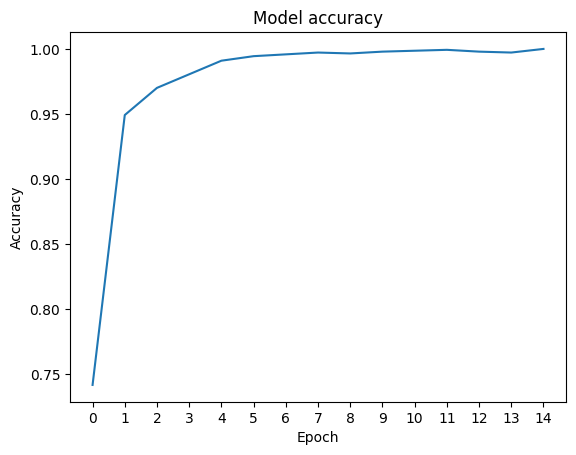

In [17]:
plt.plot(history_acc)
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(range(n_epochs))
plt.show()

## Evaluate on Test Set

In [ ]:
# After training the neural network, we set it 
# to evaluation mode and compute the accuracy on the test set
net.eval()

# We use torch.no_grad() to disable gradient computation, since we are only
# interested in the predictions and not in updating the weights of the neural network
# This can save memory and speed up the computation during evaluation
with torch.no_grad():
    # Compute the predicted labels for the test set by taking the index
    # of the maximum output value for each sample in the test set
    preds = net(X_test_t).argmax(dim=1)
    accuracy = (preds == y_test_t).float().mean().item()

print(f"Test accuracy: {accuracy:.2f}")

Test accuracy: 0.98
